In [1]:
# pasirenkamos S&P 500 akcijos
akcijos = [
    "AAPL",   # Apple
    "MSFT",   # Microsoft
    "NVDA",   # Nvidia
    "AMZN",   # Amazon
    "GOOGL",  # Alphabet Class A
    "GOOG",   # Alphabet Class C
    "META",   # Meta Platforms
    "BRK.B",  # Berkshire Hathaway
    "LLY",    # Eli Lilly
    "AVGO",   # Broadcom
    "JPM",    # JPMorgan Chase
    "V",      # Visa
    "XOM",    # Exxon Mobil
    "MA",     # Mastercard
    "UNH",    # UnitedHealth
    "PG",     # Procter & Gamble
    "JNJ",    # Johnson & Johnson
    "HD",     # Home Depot
    "COST",   # Costco
    "ORCL",   # Oracle
    "MRK",    # Merck
    "ABBV",   # AbbVie
    "CRM",    # Salesforce
    "NFLX",   # Netflix
    "KO",     # Coca-Cola
    "PEP",    # PepsiCo
    "TMO",    # Thermo Fisher Scientific
    "WMT",    # Walmart
    "CSCO",   # Cisco
    "ACN",    # Accenture
    "ADBE",   # Adobe
    "AMD",    # AMD
    "BAC",    # Bank of America
    "LIN",    # Linde
    "MCD",    # McDonald's
    "DIS",    # Disney
    "INTU",   # Intuit
    "TXN",    # Texas Instruments
    "AMGN",   # Amgen
    "QCOM",   # Qualcomm
    "PM",     # Philip Morris
    "IBM",    # IBM
    "GE",     # GE Aerospace
    "CAT",    # Caterpillar
    "GS",     # Goldman Sachs
    "SPGI",   # S&P Global
    "ISRG",   # Intuitive Surgical
    "NOW",    # ServiceNow
    "UNP",    # Union Pacific
    "BKNG"    # Booking Holdings
]

print(akcijos)

['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'GOOG', 'META', 'BRK.B', 'LLY', 'AVGO', 'JPM', 'V', 'XOM', 'MA', 'UNH', 'PG', 'JNJ', 'HD', 'COST', 'ORCL', 'MRK', 'ABBV', 'CRM', 'NFLX', 'KO', 'PEP', 'TMO', 'WMT', 'CSCO', 'ACN', 'ADBE', 'AMD', 'BAC', 'LIN', 'MCD', 'DIS', 'INTU', 'TXN', 'AMGN', 'QCOM', 'PM', 'IBM', 'GE', 'CAT', 'GS', 'SPGI', 'ISRG', 'NOW', 'UNP', 'BKNG']


In [3]:
import warnings
warnings.filterwarnings("ignore", message="Timestamp\\.utcnow is deprecated")

import yfinance as yf
import pandas as pd
import numpy as np

# -----------------------------------
# 1. Bendri nustatymai
# -----------------------------------

pradzia = "2017-01-01"
pabaiga = "2025-01-01"

# akcijos turi būti jau apibrėžtos, pvz.:
# akcijos = ["AAPL", "MSFT", "AMZN", "GOOGL", "JNJ", "XOM", "JPM", "PG"]

# Blogos rinkos scenarijus
blogos_train_pradzia = "2019-01-01"
blogos_train_pabaiga = "2021-12-31"
blogos_test_pradzia = "2022-01-01"
blogos_test_pabaiga = "2022-12-31"

# Geros rinkos scenarijus
geros_train_pradzia = "2020-01-01"
geros_train_pabaiga = "2022-12-31"
geros_test_pradzia = "2023-01-01"
geros_test_pabaiga = "2023-12-31"


# -----------------------------------
# 2. Duomenų atsisiuntimo ir paruošimo funkcija
# -----------------------------------

def gauti_kainas(akciju_sarasas, pradzia, pabaiga):
    duomenys = yf.download(
        akciju_sarasas,
        start=pradzia,
        end=pabaiga,
        interval="1d",
        progress=False,
        auto_adjust=True
    )

    kainos = duomenys["Close"].copy()  # kainos jau įvertina dividendus ir split'us
    kainos = kainos.dropna(how="all")  # pašalinamos visiškai tuščios dienos
    kainos = kainos.ffill()            # užpildomos trūkstamos reikšmės paskutine žinoma kaina
    kainos = kainos.dropna(axis=1)     # pašalinamos akcijos, kuriose vis dar yra trūkumų

    return kainos


# -----------------------------------
# 3. Atsisiunčiami visi kainų duomenys
# -----------------------------------

kainos = gauti_kainas(akcijos, pradzia, pabaiga)

print("Likusios akcijos:", len(kainos.columns))
print("Akcijų sąrašas:", kainos.columns.tolist())


# -----------------------------------
# 4. Funkcija scenarijaus duomenims paruošti
# -----------------------------------

def paruosti_scenariju(kainos, train_pradzia, train_pabaiga, test_pradzia, test_pabaiga):
    train_kainos = kainos.loc[train_pradzia:train_pabaiga].copy()
    test_kainos = kainos.loc[test_pradzia:test_pabaiga].copy()

    # Skaičiuojamos dieninės grąžos
    train_grazos = train_kainos.pct_change().dropna()
    test_grazos = test_kainos.pct_change().dropna()

    # Metinės vidutinės grąžos ir kovariacijų matrica
    vid_grazos = train_grazos.mean() * 252
    kov_matrica = train_grazos.cov() * 252

    return {
        "train_kainos": train_kainos,
        "test_kainos": test_kainos,
        "train_grazos": train_grazos,
        "test_grazos": test_grazos,
        "vid_grazos": vid_grazos,
        "kov_matrica": kov_matrica
    }


# -----------------------------------
# 5. Paruošiami abu rinkos scenarijai
# -----------------------------------

blogos_rinkos = paruosti_scenariju(
    kainos,
    blogos_train_pradzia, blogos_train_pabaiga,
    blogos_test_pradzia, blogos_test_pabaiga
)

geros_rinkos = paruosti_scenariju(
    kainos,
    geros_train_pradzia, geros_train_pabaiga,
    geros_test_pradzia, geros_test_pabaiga
)


# -----------------------------------
# 6. Rezultatų patikra
# -----------------------------------

print("\n--- BLOGOS RINKOS SCENARIJUS ---")
print("Train grąžų dydis:", blogos_rinkos["train_grazos"].shape)
print("Test grąžų dydis:", blogos_rinkos["test_grazos"].shape)
print("\nMetinės vidutinės grąžos:")
print(blogos_rinkos["vid_grazos"])
print("\nKovariacijų matrica:")
print(blogos_rinkos["kov_matrica"])

print("\n--- GEROS RINKOS SCENARIJUS ---")
print("Train grąžų dydis:", geros_rinkos["train_grazos"].shape)
print("Test grąžų dydis:", geros_rinkos["test_grazos"].shape)
print("\nMetinės vidutinės grąžos:")
print(geros_rinkos["vid_grazos"])
print("\nKovariacijų matrica:")
print(geros_rinkos["kov_matrica"])

$BRK.B: possibly delisted; no timezone found

1 Failed download:
['BRK.B']: possibly delisted; no timezone found


Likusios akcijos: 49
Akcijų sąrašas: ['AAPL', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AMGN', 'AMZN', 'AVGO', 'BAC', 'BKNG', 'CAT', 'COST', 'CRM', 'CSCO', 'DIS', 'GE', 'GOOG', 'GOOGL', 'GS', 'HD', 'IBM', 'INTU', 'ISRG', 'JNJ', 'JPM', 'KO', 'LIN', 'LLY', 'MA', 'MCD', 'META', 'MRK', 'MSFT', 'NFLX', 'NOW', 'NVDA', 'ORCL', 'PEP', 'PG', 'PM', 'QCOM', 'SPGI', 'TMO', 'TXN', 'UNH', 'UNP', 'V', 'WMT', 'XOM']

--- BLOGOS RINKOS SCENARIJUS ---
Train grąžų dydis: (756, 49)
Test grąžų dydis: (250, 49)

Metinės vidutinės grąžos:
Ticker
AAPL     0.569844
ABBV     0.230864
ACN      0.414244
ADBE     0.371037
AMD      0.817233
AMGN     0.120359
AMZN     0.300859
AVGO     0.432010
BAC      0.292174
BKNG     0.184433
CAT      0.247041
COST     0.381586
CRM      0.279463
CSCO     0.205344
DIS      0.179491
GE       0.255835
GOOG     0.382941
GOOGL    0.380894
GS       0.352105
HD       0.361328
IBM      0.157444
INTU     0.467067
ISRG     0.339731
JNJ      0.147088
JPM      0.248400
KO       0.138308
LIN      0.317

In [4]:
import numpy as np
import pandas as pd

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

klasteriu_skaicius = 8

def klasterizuoti_aktyvus(train_grazos, klasteriu_skaicius=8):
    koreliaciju_matrica = train_grazos.corr()
    atstumu_matrica = np.sqrt(0.5 * (1 - koreliaciju_matrica))
    jungimo_matrica = linkage(squareform(atstumu_matrica), method="ward")
    klasteriai = fcluster(jungimo_matrica, klasteriu_skaicius, criterion="maxclust")
    klasteriu_serija = pd.Series(klasteriai, index=train_grazos.columns, name="Klasteris")
    return koreliaciju_matrica, atstumu_matrica, klasteriu_serija

def skaiciuoti_rodiklius(train_grazos):
    tiketina_metine_graza = train_grazos.mean() * 252
    volatilumas = train_grazos.std() * np.sqrt(252)
    kaupiamos_grazos = (1 + train_grazos).cumprod()
    maksimalus_nuosmukis = pd.Series(index=train_grazos.columns, dtype=float)

    for stulpelis in train_grazos.columns:
        kreive = kaupiamos_grazos[stulpelis]
        pikas = kreive.cummax()
        nuosmukis = kreive / pikas - 1
        maksimalus_nuosmukis[stulpelis] = nuosmukis.min()

    return tiketina_metine_graza, volatilumas, maksimalus_nuosmukis

def atrinkti_aktyvus_is_klasteriu_pagal_vidutini_ranga(train_grazos, klasteriu_serija):
    tiketinos_grazos, volatilumas, maksimalus_nuosmukis = skaiciuoti_rodiklius(train_grazos)

    atrinkti_aktyvai = []
    atrankos_lentele = []

    for klasterio_nr in sorted(klasteriu_serija.unique()):
        klasterio_aktyvai = klasteriu_serija[klasteriu_serija == klasterio_nr].index.tolist()

        duomenys = pd.DataFrame({
            "Tikėtina metinė grąža": tiketinos_grazos.loc[klasterio_aktyvai],
            "Volatilumas": volatilumas.loc[klasterio_aktyvai],
            "Maksimalus nuosmukis": maksimalus_nuosmukis.loc[klasterio_aktyvai]
        }).dropna()

        if len(duomenys) == 0:
            continue

        duomenys["Grąžos rangas"] = duomenys["Tikėtina metinė grąža"].rank(ascending=False, method="average")
        duomenys["Rizikos rangas"] = duomenys["Volatilumas"].rank(ascending=True, method="average")
        duomenys["Nuosmukio rangas"] = duomenys["Maksimalus nuosmukis"].rank(ascending=False, method="average")
        duomenys["Vidutinis rangas"] = duomenys[["Grąžos rangas", "Rizikos rangas", "Nuosmukio rangas"]].mean(axis=1)

        geriausias_aktyvas = duomenys["Vidutinis rangas"].idxmin()

        atrinkti_aktyvai.append(geriausias_aktyvas)

        atrankos_lentele.append({
            "Klasteris": klasterio_nr,
            "Aktyvai klasteryje": ", ".join(klasterio_aktyvai),
            "Atrinktas aktyvas": geriausias_aktyvas,
            "Tikėtina metinė grąža": duomenys.loc[geriausias_aktyvas, "Tikėtina metinė grąža"],
            "Volatilumas": duomenys.loc[geriausias_aktyvas, "Volatilumas"],
            "Maksimalus nuosmukis": duomenys.loc[geriausias_aktyvas, "Maksimalus nuosmukis"],
            "Vidutinis rangas": duomenys.loc[geriausias_aktyvas, "Vidutinis rangas"]
        })

    atrankos_df = pd.DataFrame(atrankos_lentele)

    return atrinkti_aktyvai, atrankos_df, tiketinos_grazos, volatilumas, maksimalus_nuosmukis

def vykdyti_aktyvu_atranka(scenarijaus_duomenys, klasteriu_skaicius=8):
    train_grazos = scenarijaus_duomenys["train_grazos"]

    koreliaciju_matrica, atstumu_matrica, klasteriu_serija = klasterizuoti_aktyvus(
        train_grazos,
        klasteriu_skaicius=klasteriu_skaicius
    )

    atrinkti_aktyvai, atrankos_df, tiketinos_grazos, volatilumas, maksimalus_nuosmukis = atrinkti_aktyvus_is_klasteriu_pagal_vidutini_ranga(
        train_grazos,
        klasteriu_serija
    )

    return {
        "koreliaciju_matrica": koreliaciju_matrica,
        "atstumu_matrica": atstumu_matrica,
        "klasteriu_serija": klasteriu_serija,
        "tiketinos_grazos": tiketinos_grazos,
        "volatilumas": volatilumas,
        "maksimalus_nuosmukis": maksimalus_nuosmukis,
        "atrinkti_aktyvai": atrinkti_aktyvai,
        "atrankos_df": atrankos_df
    }

blogos_atranka = vykdyti_aktyvu_atranka(
    blogos_rinkos,
    klasteriu_skaicius=klasteriu_skaicius
)

print("=== BLOGOS RINKOS ATRINKTI AKTYVAI ===")
print(blogos_atranka["atrinkti_aktyvai"])
print()
print(blogos_atranka["atrankos_df"])

geros_atranka = vykdyti_aktyvu_atranka(
    geros_rinkos,
    klasteriu_skaicius=klasteriu_skaicius
)

print("\n=== GEROS RINKOS ATRINKTI AKTYVAI ===")
print(geros_atranka["atrinkti_aktyvai"])
print()
print(geros_atranka["atrankos_df"])

=== BLOGOS RINKOS ATRINKTI AKTYVAI ===
['TXN', 'MSFT', 'UNP', 'ACN', 'LLY', 'COST', 'ORCL', 'PG']

   Klasteris                                 Aktyvai klasteryje  \
0          1                         AMD, AVGO, NVDA, QCOM, TXN   
1          2  AAPL, ADBE, AMZN, CRM, GOOG, GOOGL, INTU, META...   
2          3         BAC, BKNG, CAT, DIS, GE, GS, JPM, UNP, XOM   
3          4               ACN, HD, ISRG, LIN, MA, MCD, SPGI, V   
4          5                ABBV, AMGN, JNJ, LLY, MRK, TMO, UNH   
5          6                                          COST, WMT   
6          7                                    CSCO, IBM, ORCL   
7          8                                    KO, PEP, PG, PM   

  Atrinktas aktyvas  Tikėtina metinė grąža  Volatilumas  Maksimalus nuosmukis  \
0               TXN               0.311636     0.330793             -0.298507   
1              MSFT               0.458171     0.303425             -0.280393   
2               UNP               0.268497     0.30434

In [5]:
blogos_train_atrinktos = blogos_rinkos["train_grazos"][blogos_atranka["atrinkti_aktyvai"]]
blogos_test_atrinktos = blogos_rinkos["test_grazos"][blogos_atranka["atrinkti_aktyvai"]]

geros_train_atrinktos = geros_rinkos["train_grazos"][geros_atranka["atrinkti_aktyvai"]]
geros_test_atrinktos = geros_rinkos["test_grazos"][geros_atranka["atrinkti_aktyvai"]]

blogos_vid_grazos = blogos_train_atrinktos.mean() * 252
blogos_kov_matrica = blogos_train_atrinktos.cov() * 252

geros_vid_grazos = geros_train_atrinktos.mean() * 252
geros_kov_matrica = geros_train_atrinktos.cov() * 252

In [12]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# -------------------------------------------------
# MAKSIMALAUS SHARPE PORTFELIS - BLOGA IR GERA RINKA
# -------------------------------------------------

nerizikingu_palukanu_norma = 0.02

# -------------------------------------------------
# 1. Pagalbinės funkcijos
# -------------------------------------------------
def portfelio_rodikliai(svoriai, vid_grazos, kov_matrica):
    portfelio_graza = np.sum(svoriai * vid_grazos)
    portfelio_rizika = np.sqrt(np.dot(svoriai.T, np.dot(kov_matrica, svoriai)))
    return portfelio_graza, portfelio_rizika

def neigiamas_sharpe(svoriai, vid_grazos, kov_matrica, nerizikingu_palukanu_norma=0.02):
    portfelio_graza, portfelio_rizika = portfelio_rodikliai(svoriai, vid_grazos, kov_matrica)
    if portfelio_rizika == 0:
        return 1e6
    sharpe = (portfelio_graza - nerizikingu_palukanu_norma) / portfelio_rizika
    return -sharpe

def maksimalus_nuosmukis_is_dienos_grazu(dienos_grazos):
    kaupiamoji_graza = (1 + dienos_grazos).cumprod()
    ankstesnis_pikas = kaupiamoji_graza.cummax()
    nuosmukis = (kaupiamoji_graza - ankstesnis_pikas) / ankstesnis_pikas
    return nuosmukis.min()

def efektyvus_aktyvu_skaicius(svoriai):
    return 1 / np.sum(np.square(svoriai))

def vykdyti_maks_sharpe_portfeli(train_grazos, test_grazos, scenarijaus_pavadinimas, nerizikingu_palukanu_norma=0.02):
    # ---------------------------------------------
    # 2. Train periodo statistika
    # ---------------------------------------------
    vid_grazos = train_grazos.mean() * 252
    kov_matrica = train_grazos.cov() * 252
    aktyvu_skaicius = len(vid_grazos)

    # ---------------------------------------------
    # 3. Optimizacijos nustatymai
    # ---------------------------------------------
    apribojimai = ({
        "type": "eq",
        "fun": lambda x: np.sum(x) - 1
    })

    ribos = tuple((0, 1) for _ in range(aktyvu_skaicius))
    pradiniai_svoriai = np.ones(aktyvu_skaicius) / aktyvu_skaicius

    # ---------------------------------------------
    # 4. Maksimizuojamas Sharpe santykis
    # ---------------------------------------------
    optimizavimo_rezultatas = minimize(
        neigiamas_sharpe,
        pradiniai_svoriai,
        args=(vid_grazos, kov_matrica, nerizikingu_palukanu_norma),
        method="SLSQP",
        bounds=ribos,
        constraints=apribojimai
    )

    maksimalaus_sharpe_svoriai = np.array(optimizavimo_rezultatas.x)

    svoriai_lentele_ms = pd.DataFrame({
        "Aktyvas": vid_grazos.index,
        "Svoris": maksimalaus_sharpe_svoriai
    }).sort_values("Svoris", ascending=False)

    # ---------------------------------------------
    # 5. Treniruotės rodikliai
    # ---------------------------------------------
    maksimalaus_sharpe_graza, maksimalaus_sharpe_rizika = portfelio_rodikliai(
        maksimalaus_sharpe_svoriai,
        vid_grazos,
        kov_matrica
    )

    if maksimalaus_sharpe_rizika == 0:
        maksimalaus_sharpe_sharpe = np.nan
    else:
        maksimalaus_sharpe_sharpe = (
            maksimalaus_sharpe_graza - nerizikingu_palukanu_norma
        ) / maksimalaus_sharpe_rizika

    train_ena = efektyvus_aktyvu_skaicius(maksimalaus_sharpe_svoriai)

    # ---------------------------------------------
    # 6. Test periodo rodikliai
    # ---------------------------------------------
    testo_portfelio_dienos_grazos_ms = test_grazos.dot(maksimalaus_sharpe_svoriai)

    testo_graza_ms = testo_portfelio_dienos_grazos_ms.mean() * 252
    testo_rizika_ms = testo_portfelio_dienos_grazos_ms.std() * np.sqrt(252)

    if testo_rizika_ms == 0:
        testo_sharpe_ms = np.nan
    else:
        testo_sharpe_ms = (
            testo_graza_ms - nerizikingu_palukanu_norma
        ) / testo_rizika_ms

    kaupiamoji_graza_ms = (1 + testo_portfelio_dienos_grazos_ms).cumprod()
    bendra_kaupiamoji_graza_ms = kaupiamoji_graza_ms.iloc[-1] - 1

    maksimalus_nuosmukis_ms = maksimalus_nuosmukis_is_dienos_grazu(
        testo_portfelio_dienos_grazos_ms
    )

    tiksline_dienos_graza = nerizikingu_palukanu_norma / 252
    neigiami_nukrypimai_ms = (
        testo_portfelio_dienos_grazos_ms[testo_portfelio_dienos_grazos_ms < tiksline_dienos_graza]
        - tiksline_dienos_graza
    )

    if len(neigiami_nukrypimai_ms) == 0:
        downside_rizika_ms = 0.0
    else:
        downside_rizika_ms = np.sqrt((neigiami_nukrypimai_ms ** 2).mean()) * np.sqrt(252)

    test_ena = efektyvus_aktyvu_skaicius(maksimalaus_sharpe_svoriai)

    # ---------------------------------------------
    # 7. Spausdinimas
    # ---------------------------------------------
    print(f"\n=== Maksimalaus Sharpe portfelis: {scenarijaus_pavadinimas.upper()} rinka ===")
    print("\nSvoriai:")
    print(svoriai_lentele_ms.round(4))

    print("\nTreniravimo rodikliai:")
    print(f"Metinė grąža: {maksimalaus_sharpe_graza:.4f}")
    print(f"Metinė rizika: {maksimalaus_sharpe_rizika:.4f}")
    print(f"Sharpe santykis: {maksimalaus_sharpe_sharpe:.4f}")
    print(f"ENA: {train_ena:.4f}")

    print("\nNe imties testavimo rodikliai:")
    print(f"Metinė grąža: {testo_graza_ms:.4f}")
    print(f"Metinė rizika: {testo_rizika_ms:.4f}")
    print(f"Sharpe santykis: {testo_sharpe_ms:.4f}")
    print(f"Kaupiamoji grąža: {bendra_kaupiamoji_graza_ms:.4f}")
    print(f"Maksimalus nuosmukis: {maksimalus_nuosmukis_ms:.4f}")
    print(f"Downside rizika: {downside_rizika_ms:.4f}")
    print(f"ENA: {test_ena:.4f}")

    # ---------------------------------------------
    # 8. Rezultatų grąžinimas
    # ---------------------------------------------
    rezultatai = {
        "Scenarijus": scenarijaus_pavadinimas,
        "Strategija": "Maksimalaus Sharpe",
        "Train metinė grąža": maksimalaus_sharpe_graza,
        "Train metinė rizika": maksimalaus_sharpe_rizika,
        "Train Sharpe": maksimalaus_sharpe_sharpe,
        "Test metinė grąža": testo_graza_ms,
        "Test metinė rizika": testo_rizika_ms,
        "Test Sharpe": testo_sharpe_ms,
        "Test kaupiamoji grąža": bendra_kaupiamoji_graza_ms,
        "Test maksimalus nuosmukis": maksimalus_nuosmukis_ms,
        "Test downside rizika": downside_rizika_ms,
        "ENA": test_ena
    }

    return svoriai_lentele_ms, pd.DataFrame([rezultatai]), testo_portfelio_dienos_grazos_ms, kaupiamoji_graza_ms


# -------------------------------------------------
# 9. BLOGA RINKA
# -------------------------------------------------
maks_sharpe_lentele_bloga, maks_sharpe_rezultatai_bloga, dienos_ms_bloga, kaupiamoji_ms_bloga = vykdyti_maks_sharpe_portfeli(
    blogos_train_atrinktos,
    blogos_test_atrinktos,
    scenarijaus_pavadinimas="bloga",
    nerizikingu_palukanu_norma=nerizikingu_palukanu_norma
)

# -------------------------------------------------
# 10. GERA RINKA
# -------------------------------------------------
maks_sharpe_lentele_gera, maks_sharpe_rezultatai_gera, dienos_ms_gera, kaupiamoji_ms_gera = vykdyti_maks_sharpe_portfeli(
    geros_train_atrinktos,
    geros_test_atrinktos,
    scenarijaus_pavadinimas="gera",
    nerizikingu_palukanu_norma=nerizikingu_palukanu_norma
)

# -------------------------------------------------
# 11. Bendra suvestinė lentelė
# -------------------------------------------------
maks_sharpe_rezultatai_visi = pd.concat(
    [maks_sharpe_rezultatai_bloga, maks_sharpe_rezultatai_gera],
    ignore_index=True
)

print("\n=== BENDRA MAKSIMALAUS SHARPE PORTFELIO SUVESTINĖ ===")
print(maks_sharpe_rezultatai_visi.round(4))


=== Maksimalaus Sharpe portfelis: BLOGA rinka ===

Svoriai:
  Aktyvas  Svoris
5    COST  0.5745
3     ACN  0.2043
1    MSFT  0.1119
4     LLY  0.1093
2     UNP  0.0000
0     TXN  0.0000
6    ORCL  0.0000
7      PG  0.0000

Treniravimo rodikliai:
Metinė grąža: 0.3950
Metinė rizika: 0.2111
Sharpe santykis: 1.7760
ENA: 2.5235

Ne imties testavimo rodikliai:
Metinė grąža: -0.1569
Metinė rizika: 0.2732
Sharpe santykis: -0.6474
Kaupiamoji grąža: -0.1754
Maksimalus nuosmukis: -0.2437
Downside rizika: 0.2881
ENA: 2.5235

=== Maksimalaus Sharpe portfelis: GERA rinka ===

Svoriai:
  Aktyvas  Svoris
4     LLY  0.6592
0    AVGO  0.1524
5     CAT  0.1325
7     TMO  0.0559
3      PG  0.0000
6     LIN  0.0000
2     WMT  0.0000
1    AAPL  0.0000

Treniravimo rodikliai:
Metinė grąža: 0.3638
Metinė rizika: 0.2826
Sharpe santykis: 1.2163
ENA: 2.0901

Ne imties testavimo rodikliai:
Metinė grąža: 0.5014
Metinė rizika: 0.2117
Sharpe santykis: 2.2740
Kaupiamoji grąža: 0.6052
Maksimalus nuosmukis: -0.1034
Do

In [7]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# -------------------------------------------------
# MINIMALIOS RIZIKOS PORTFELIS - BLOGA IR GERA RINKA
# -------------------------------------------------

nerizikingu_palukanu_norma = 0.02

# -------------------------------------------------
# 1. Pagalbinės funkcijos
# -------------------------------------------------
def portfelio_rodikliai(svoriai, vid_grazos, kov_matrica):
    portfelio_graza = np.sum(svoriai * vid_grazos)
    portfelio_rizika = np.sqrt(np.dot(svoriai.T, np.dot(kov_matrica, svoriai)))
    return portfelio_graza, portfelio_rizika

def portfelio_rizika(svoriai, kov_matrica):
    return np.sqrt(np.dot(svoriai.T, np.dot(kov_matrica, svoriai)))

def maksimalus_nuosmukis_is_dienos_grazu(dienos_grazos):
    kaupiamoji_graza = (1 + dienos_grazos).cumprod()
    ankstesnis_pikas = kaupiamoji_graza.cummax()
    nuosmukis = (kaupiamoji_graza - ankstesnis_pikas) / ankstesnis_pikas
    return nuosmukis.min()

def efektyvus_aktyvu_skaicius(svoriai):
    return 1 / np.sum(np.square(svoriai))

def vykdyti_minimalios_rizikos_portfeli(train_grazos, test_grazos, scenarijaus_pavadinimas, nerizikingu_palukanu_norma=0.02):
    # ---------------------------------------------
    # 2. Train periodo statistika
    # ---------------------------------------------
    vid_grazos = train_grazos.mean() * 252
    kov_matrica = train_grazos.cov() * 252
    aktyvu_skaicius = len(vid_grazos)

    # ---------------------------------------------
    # 3. Optimizacijos nustatymai
    # ---------------------------------------------
    apribojimai = ({
        "type": "eq",
        "fun": lambda x: np.sum(x) - 1
    })

    ribos = tuple((0, 1) for _ in range(aktyvu_skaicius))
    pradiniai_svoriai = np.ones(aktyvu_skaicius) / aktyvu_skaicius

    # ---------------------------------------------
    # 4. Minimizuojama portfelio rizika
    # ---------------------------------------------
    minimalios_dispersijos_rezultatas = minimize(
        portfelio_rizika,
        pradiniai_svoriai,
        args=(kov_matrica,),
        method="SLSQP",
        bounds=ribos,
        constraints=apribojimai
    )

    minimalios_dispersijos_svoriai = np.array(minimalios_dispersijos_rezultatas.x)

    svoriai_lentele_md = pd.DataFrame({
        "Aktyvas": vid_grazos.index,
        "Svoris": minimalios_dispersijos_svoriai
    }).sort_values("Svoris", ascending=False)

    # ---------------------------------------------
    # 5. Treniruotės rodikliai
    # ---------------------------------------------
    minimalios_dispersijos_graza, minimalios_dispersijos_rizika = portfelio_rodikliai(
        minimalios_dispersijos_svoriai,
        vid_grazos,
        kov_matrica
    )

    if minimalios_dispersijos_rizika == 0:
        minimalios_dispersijos_sharpe = np.nan
    else:
        minimalios_dispersijos_sharpe = (
            minimalios_dispersijos_graza - nerizikingu_palukanu_norma
        ) / minimalios_dispersijos_rizika

    train_ena = efektyvus_aktyvu_skaicius(minimalios_dispersijos_svoriai)

    # ---------------------------------------------
    # 6. Test periodo rodikliai
    # ---------------------------------------------
    testo_portfelio_dienos_grazos_md = test_grazos.dot(minimalios_dispersijos_svoriai)

    testo_graza_md = testo_portfelio_dienos_grazos_md.mean() * 252
    testo_rizika_md = testo_portfelio_dienos_grazos_md.std() * np.sqrt(252)

    if testo_rizika_md == 0:
        testo_sharpe_md = np.nan
    else:
        testo_sharpe_md = (
            testo_graza_md - nerizikingu_palukanu_norma
        ) / testo_rizika_md

    kaupiamoji_graza_md = (1 + testo_portfelio_dienos_grazos_md).cumprod()
    bendra_kaupiamoji_graza_md = kaupiamoji_graza_md.iloc[-1] - 1

    maksimalus_nuosmukis_md = maksimalus_nuosmukis_is_dienos_grazu(
        testo_portfelio_dienos_grazos_md
    )

    tiksline_dienos_graza = nerizikingu_palukanu_norma / 252
    neigiami_nukrypimai_md = (
        testo_portfelio_dienos_grazos_md[testo_portfelio_dienos_grazos_md < tiksline_dienos_graza]
        - tiksline_dienos_graza
    )

    if len(neigiami_nukrypimai_md) == 0:
        downside_rizika_md = 0.0
    else:
        downside_rizika_md = np.sqrt((neigiami_nukrypimai_md ** 2).mean()) * np.sqrt(252)

    test_ena = efektyvus_aktyvu_skaicius(minimalios_dispersijos_svoriai)

    # ---------------------------------------------
    # 7. Spausdinimas
    # ---------------------------------------------
    print(f"\n=== Minimalios rizikos portfelis: {scenarijaus_pavadinimas.upper()} rinka ===")
    print("\nSvoriai:")
    print(svoriai_lentele_md.round(4))

    print("\nTreniravimo rodikliai:")
    print(f"Metinė grąža: {minimalios_dispersijos_graza:.4f}")
    print(f"Metinė rizika: {minimalios_dispersijos_rizika:.4f}")
    print(f"Sharpe santykis: {minimalios_dispersijos_sharpe:.4f}")
    print(f"ENA: {train_ena:.4f}")

    print("\nNe imties testavimo rodikliai:")
    print(f"Metinė grąža: {testo_graza_md:.4f}")
    print(f"Metinė rizika: {testo_rizika_md:.4f}")
    print(f"Sharpe santykis: {testo_sharpe_md:.4f}")
    print(f"Kaupiamoji grąža: {bendra_kaupiamoji_graza_md:.4f}")
    print(f"Maksimalus nuosmukis: {maksimalus_nuosmukis_md:.4f}")
    print(f"Downside rizika: {downside_rizika_md:.4f}")
    print(f"ENA: {test_ena:.4f}")

    # ---------------------------------------------
    # 8. Rezultatų grąžinimas
    # ---------------------------------------------
    rezultatai = {
        "Scenarijus": scenarijaus_pavadinimas,
        "Strategija": "Minimalios rizikos",
        "Train metinė grąža": minimalios_dispersijos_graza,
        "Train metinė rizika": minimalios_dispersijos_rizika,
        "Train Sharpe": minimalios_dispersijos_sharpe,
        "Test metinė grąža": testo_graza_md,
        "Test metinė rizika": testo_rizika_md,
        "Test Sharpe": testo_sharpe_md,
        "Test kaupiamoji grąža": bendra_kaupiamoji_graza_md,
        "Test maksimalus nuosmukis": maksimalus_nuosmukis_md,
        "Test downside rizika": downside_rizika_md,
        "ENA": test_ena
    }

    return svoriai_lentele_md, pd.DataFrame([rezultatai]), testo_portfelio_dienos_grazos_md, kaupiamoji_graza_md


# -------------------------------------------------
# 9. BLOGA RINKA
# -------------------------------------------------
minimalios_rizikos_lentele_bloga, minimalios_rizikos_rezultatai_bloga, dienos_md_bloga, kaupiamoji_md_bloga = vykdyti_minimalios_rizikos_portfeli(
    blogos_train_atrinktos,
    blogos_test_atrinktos,
    scenarijaus_pavadinimas="bloga",
    nerizikingu_palukanu_norma=nerizikingu_palukanu_norma
)

# -------------------------------------------------
# 10. GERA RINKA
# -------------------------------------------------
minimalios_rizikos_lentele_gera, minimalios_rizikos_rezultatai_gera, dienos_md_gera, kaupiamoji_md_gera = vykdyti_minimalios_rizikos_portfeli(
    geros_train_atrinktos,
    geros_test_atrinktos,
    scenarijaus_pavadinimas="gera",
    nerizikingu_palukanu_norma=nerizikingu_palukanu_norma
)

# -------------------------------------------------
# 11. Bendra suvestinė lentelė
# -------------------------------------------------
minimalios_rizikos_rezultatai_visi = pd.concat(
    [minimalios_rizikos_rezultatai_bloga, minimalios_rizikos_rezultatai_gera],
    ignore_index=True
)

print("\n=== BENDRA MINIMALIOS RIZIKOS PORTFELIO SUVESTINĖ ===")
print(minimalios_rizikos_rezultatai_visi.round(4))


=== Minimalios rizikos portfelis: BLOGA rinka ===

Svoriai:
  Aktyvas  Svoris
5    COST  0.4357
7      PG  0.3339
2     UNP  0.1501
4     LLY  0.0802
0     TXN  0.0000
6    ORCL  0.0000
3     ACN  0.0000
1    MSFT  0.0000

Treniravimo rodikliai:
Metinė grąža: 0.3179
Metinė rizika: 0.1922
Sharpe santykis: 1.5494
ENA: 3.0274

Ne imties testavimo rodikliai:
Metinė grąža: -0.0687
Metinė rizika: 0.2203
Sharpe santykis: -0.4025
Kaupiamoji grąža: -0.0882
Maksimalus nuosmukis: -0.2013
Downside rizika: 0.2317
ENA: 3.0274

=== Minimalios rizikos portfelis: GERA rinka ===

Svoriai:
  Aktyvas  Svoris
2     WMT  0.3306
3      PG  0.3196
5     CAT  0.1312
7     TMO  0.1195
4     LLY  0.0864
6     LIN  0.0128
0    AVGO  0.0000
1    AAPL  0.0000

Treniravimo rodikliai:
Metinė grąža: 0.1721
Metinė rizika: 0.2071
Sharpe santykis: 0.7341
ENA: 3.9913

Ne imties testavimo rodikliai:
Metinė grąža: 0.1249
Metinė rizika: 0.1153
Sharpe santykis: 0.9105
Kaupiamoji grąža: 0.1240
Maksimalus nuosmukis: -0.0790
Do

In [9]:
import numpy as np
import pandas as pd

# -------------------------------------------------
# LYGIASVORIS PORTFELIS - BLOGA IR GERA RINKA
# -------------------------------------------------

nerizikingu_palukanu_norma = 0.02

# -------------------------------------------------
# 1. Pagalbinės funkcijos
# -------------------------------------------------
def portfelio_rodikliai(svoriai, vid_grazos, kov_matrica):
    portfelio_graza = np.sum(svoriai * vid_grazos)
    portfelio_rizika = np.sqrt(np.dot(svoriai.T, np.dot(kov_matrica, svoriai)))
    return portfelio_graza, portfelio_rizika

def maksimalus_nuosmukis_is_dienos_grazu(dienos_grazos):
    kaupiamoji_graza = (1 + dienos_grazos).cumprod()
    ankstesnis_pikas = kaupiamoji_graza.cummax()
    nuosmukis = (kaupiamoji_graza - ankstesnis_pikas) / ankstesnis_pikas
    return nuosmukis.min()

def efektyvus_aktyvu_skaicius(svoriai):
    return 1 / np.sum(np.square(svoriai))

def vykdyti_lygiasvori_portfeli(train_grazos, test_grazos, scenarijaus_pavadinimas, nerizikingu_palukanu_norma=0.02):
    # ---------------------------------------------
    # 2. Train periodo statistika
    # ---------------------------------------------
    vid_grazos = train_grazos.mean() * 252
    kov_matrica = train_grazos.cov() * 252
    aktyvu_skaicius = len(vid_grazos)

    # ---------------------------------------------
    # 3. Lygūs svoriai
    # ---------------------------------------------
    lygus_svoriai = np.ones(aktyvu_skaicius) / aktyvu_skaicius

    svoriai_lentele_lv = pd.DataFrame({
        "Aktyvas": vid_grazos.index,
        "Svoris": lygus_svoriai
    }).sort_values("Aktyvas")

    # ---------------------------------------------
    # 4. Treniruotės rodikliai
    # ---------------------------------------------
    lygiasvorio_graza, lygiasvorio_rizika = portfelio_rodikliai(
        lygus_svoriai,
        vid_grazos,
        kov_matrica
    )

    if lygiasvorio_rizika == 0:
        lygiasvorio_sharpe = np.nan
    else:
        lygiasvorio_sharpe = (
            lygiasvorio_graza - nerizikingu_palukanu_norma
        ) / lygiasvorio_rizika

    train_ena = efektyvus_aktyvu_skaicius(lygus_svoriai)

    # ---------------------------------------------
    # 5. Test periodo rodikliai
    # ---------------------------------------------
    testo_portfelio_dienos_grazos_lv = test_grazos.dot(lygus_svoriai)

    testo_graza_lv = testo_portfelio_dienos_grazos_lv.mean() * 252
    testo_rizika_lv = testo_portfelio_dienos_grazos_lv.std() * np.sqrt(252)

    if testo_rizika_lv == 0:
        testo_sharpe_lv = np.nan
    else:
        testo_sharpe_lv = (
            testo_graza_lv - nerizikingu_palukanu_norma
        ) / testo_rizika_lv

    kaupiamoji_graza_lv = (1 + testo_portfelio_dienos_grazos_lv).cumprod()
    bendra_kaupiamoji_graza_lv = kaupiamoji_graza_lv.iloc[-1] - 1

    maksimalus_nuosmukis_lv = maksimalus_nuosmukis_is_dienos_grazu(
        testo_portfelio_dienos_grazos_lv
    )

    tiksline_dienos_graza = nerizikingu_palukanu_norma / 252
    neigiami_nukrypimai_lv = (
        testo_portfelio_dienos_grazos_lv[testo_portfelio_dienos_grazos_lv < tiksline_dienos_graza]
        - tiksline_dienos_graza
    )

    if len(neigiami_nukrypimai_lv) == 0:
        downside_rizika_lv = 0.0
    else:
        downside_rizika_lv = np.sqrt((neigiami_nukrypimai_lv ** 2).mean()) * np.sqrt(252)

    test_ena = efektyvus_aktyvu_skaicius(lygus_svoriai)

    # ---------------------------------------------
    # 6. Spausdinimas
    # ---------------------------------------------
    print(f"\n=== Lygiasvoris portfelis: {scenarijaus_pavadinimas.upper()} rinka ===")
    print("\nSvoriai:")
    print(svoriai_lentele_lv.round(4))

    print("\nTreniravimo rodikliai:")
    print(f"Metinė grąža: {lygiasvorio_graza:.4f}")
    print(f"Metinė rizika: {lygiasvorio_rizika:.4f}")
    print(f"Sharpe santykis: {lygiasvorio_sharpe:.4f}")
    print(f"ENA: {train_ena:.4f}")

    print("\nNe imties testavimo rodikliai:")
    print(f"Metinė grąža: {testo_graza_lv:.4f}")
    print(f"Metinė rizika: {testo_rizika_lv:.4f}")
    print(f"Sharpe santykis: {testo_sharpe_lv:.4f}")
    print(f"Kaupiamoji grąža: {bendra_kaupiamoji_graza_lv:.4f}")
    print(f"Maksimalus nuosmukis: {maksimalus_nuosmukis_lv:.4f}")
    print(f"Downside rizika: {downside_rizika_lv:.4f}")
    print(f"ENA: {test_ena:.4f}")

    # ---------------------------------------------
    # 7. Rezultatų grąžinimas
    # ---------------------------------------------
    rezultatai = {
        "Scenarijus": scenarijaus_pavadinimas,
        "Strategija": "Lygiasvoris",
        "Train metinė grąža": lygiasvorio_graza,
        "Train metinė rizika": lygiasvorio_rizika,
        "Train Sharpe": lygiasvorio_sharpe,
        "Test metinė grąža": testo_graza_lv,
        "Test metinė rizika": testo_rizika_lv,
        "Test Sharpe": testo_sharpe_lv,
        "Test kaupiamoji grąža": bendra_kaupiamoji_graza_lv,
        "Test maksimalus nuosmukis": maksimalus_nuosmukis_lv,
        "Test downside rizika": downside_rizika_lv,
        "ENA": test_ena
    }

    return svoriai_lentele_lv, pd.DataFrame([rezultatai]), testo_portfelio_dienos_grazos_lv, kaupiamoji_graza_lv


# -------------------------------------------------
# 8. BLOGA RINKA
# -------------------------------------------------
lygiasvorio_lentele_bloga, lygiasvorio_rezultatai_bloga, dienos_lv_bloga, kaupiamoji_lv_bloga = vykdyti_lygiasvori_portfeli(
    blogos_train_atrinktos,
    blogos_test_atrinktos,
    scenarijaus_pavadinimas="bloga",
    nerizikingu_palukanu_norma=nerizikingu_palukanu_norma
)

# -------------------------------------------------
# 9. GERA RINKA
# -------------------------------------------------
lygiasvorio_lentele_gera, lygiasvorio_rezultatai_gera, dienos_lv_gera, kaupiamoji_lv_gera = vykdyti_lygiasvori_portfeli(
    geros_train_atrinktos,
    geros_test_atrinktos,
    scenarijaus_pavadinimas="gera",
    nerizikingu_palukanu_norma=nerizikingu_palukanu_norma
)

# -------------------------------------------------
# 10. Bendra suvestinė lentelė
# -------------------------------------------------
lygiasvorio_rezultatai_visi = pd.concat(
    [lygiasvorio_rezultatai_bloga, lygiasvorio_rezultatai_gera],
    ignore_index=True
)

print("\n=== BENDRA LYGIASVORIO PORTFELIO SUVESTINĖ ===")
print(lygiasvorio_rezultatai_visi.round(4))


=== Lygiasvoris portfelis: BLOGA rinka ===

Svoriai:
  Aktyvas  Svoris
3     ACN   0.125
5    COST   0.125
4     LLY   0.125
1    MSFT   0.125
6    ORCL   0.125
7      PG   0.125
0     TXN   0.125
2     UNP   0.125

Treniravimo rodikliai:
Metinė grąža: 0.3409
Metinė rizika: 0.2199
Sharpe santykis: 1.4597
ENA: 8.0000

Ne imties testavimo rodikliai:
Metinė grąža: -0.0818
Metinė rizika: 0.2278
Sharpe santykis: -0.4467
Kaupiamoji grąža: -0.1013
Maksimalus nuosmukis: -0.1948
Downside rizika: 0.2248
ENA: 8.0000

=== Lygiasvoris portfelis: GERA rinka ===

Svoriai:
  Aktyvas  Svoris
1    AAPL   0.125
0    AVGO   0.125
5     CAT   0.125
6     LIN   0.125
4     LLY   0.125
3      PG   0.125
7     TMO   0.125
2     WMT   0.125

Treniravimo rodikliai:
Metinė grąža: 0.2350
Metinė rizika: 0.2337
Sharpe santykis: 0.9197
ENA: 8.0000

Ne imties testavimo rodikliai:
Metinė grąža: 0.3064
Metinė rizika: 0.1279
Sharpe santykis: 2.2391
Kaupiamoji grąža: 0.3425
Maksimalus nuosmukis: -0.0807
Downside rizika:

In [10]:
import numpy as np
import pandas as pd
from skfolio.optimization import RiskBudgeting
from skfolio.measures import RiskMeasure

# -------------------------------------------------
# RIZIKOS PARITETO PORTFELIS - BLOGA IR GERA RINKA
# -------------------------------------------------

nerizikingu_palukanu_norma = 0.02

# -------------------------------------------------
# 1. Pagalbinės funkcijos
# -------------------------------------------------
def portfelio_rodikliai(svoriai, vid_grazos, kov_matrica):
    portfelio_graza = np.sum(svoriai * vid_grazos)
    portfelio_rizika = np.sqrt(np.dot(svoriai.T, np.dot(kov_matrica, svoriai)))
    return portfelio_graza, portfelio_rizika

def maksimalus_nuosmukis_is_dienos_grazu(dienos_grazos):
    kaupiamoji_graza = (1 + dienos_grazos).cumprod()
    ankstesnis_pikas = kaupiamoji_graza.cummax()
    nuosmukis = (kaupiamoji_graza - ankstesnis_pikas) / ankstesnis_pikas
    return nuosmukis.min()

def efektyvus_aktyvu_skaicius(svoriai):
    return 1 / np.sum(np.square(svoriai))

def vykdyti_rizikos_pariteta(train_grazos, test_grazos, scenarijaus_pavadinimas, nerizikingu_palukanu_norma=0.02):
    # ---------------------------------------------
    # 2. Train periodo statistika
    # ---------------------------------------------
    vid_grazos = train_grazos.mean() * 252
    kov_matrica = train_grazos.cov() * 252

    # ---------------------------------------------
    # 3. Rizikos pariteto modelis
    # ---------------------------------------------
    rizikos_pariteto_modelis = RiskBudgeting(
        risk_measure=RiskMeasure.VARIANCE,
        portfolio_params=dict(name=f"Rizikos paritetas - {scenarijaus_pavadinimas}")
    )

    rizikos_pariteto_modelis.fit(train_grazos)
    rizikos_pariteto_svoriai = np.array(rizikos_pariteto_modelis.weights_)

    rizikos_pariteto_lentele = pd.DataFrame({
        "Aktyvas": train_grazos.columns,
        "Svoris": rizikos_pariteto_svoriai
    }).sort_values("Svoris", ascending=False)

    # ---------------------------------------------
    # 4. Treniruotės rodikliai
    # ---------------------------------------------
    rizikos_pariteto_graza, rizikos_pariteto_rizika = portfelio_rodikliai(
        rizikos_pariteto_svoriai,
        vid_grazos,
        kov_matrica
    )

    if rizikos_pariteto_rizika == 0:
        rizikos_pariteto_sharpe = np.nan
    else:
        rizikos_pariteto_sharpe = (
            rizikos_pariteto_graza - nerizikingu_palukanu_norma
        ) / rizikos_pariteto_rizika

    train_ena = efektyvus_aktyvu_skaicius(rizikos_pariteto_svoriai)

    # ---------------------------------------------
    # 5. Test periodo rodikliai
    # ---------------------------------------------
    testo_portfelio_dienos_grazos_rp = test_grazos.dot(rizikos_pariteto_svoriai)

    testo_graza_rp = testo_portfelio_dienos_grazos_rp.mean() * 252
    testo_rizika_rp = testo_portfelio_dienos_grazos_rp.std() * np.sqrt(252)

    if testo_rizika_rp == 0:
        testo_sharpe_rp = np.nan
    else:
        testo_sharpe_rp = (
            testo_graza_rp - nerizikingu_palukanu_norma
        ) / testo_rizika_rp

    kaupiamoji_graza_rp = (1 + testo_portfelio_dienos_grazos_rp).cumprod()
    bendra_kaupiamoji_graza_rp = kaupiamoji_graza_rp.iloc[-1] - 1

    maksimalus_nuosmukis_rp = maksimalus_nuosmukis_is_dienos_grazu(testo_portfelio_dienos_grazos_rp)

    tiksline_dienos_graza = nerizikingu_palukanu_norma / 252
    neigiami_nukrypimai_rp = (
        testo_portfelio_dienos_grazos_rp[testo_portfelio_dienos_grazos_rp < tiksline_dienos_graza]
        - tiksline_dienos_graza
    )

    if len(neigiami_nukrypimai_rp) == 0:
        downside_rizika_rp = 0.0
    else:
        downside_rizika_rp = np.sqrt((neigiami_nukrypimai_rp ** 2).mean()) * np.sqrt(252)

    test_ena = efektyvus_aktyvu_skaicius(rizikos_pariteto_svoriai)

    # ---------------------------------------------
    # 6. Spausdinimas
    # ---------------------------------------------
    print(f"\n=== Rizikos pariteto portfelis: {scenarijaus_pavadinimas.upper()} rinka ===")
    print("\nSvoriai:")
    print(rizikos_pariteto_lentele.round(4))

    print("\nTreniravimo rodikliai:")
    print(f"Metinė grąža: {rizikos_pariteto_graza:.4f}")
    print(f"Metinė rizika: {rizikos_pariteto_rizika:.4f}")
    print(f"Sharpe santykis: {rizikos_pariteto_sharpe:.4f}")
    print(f"ENA: {train_ena:.4f}")

    print("\nNe imties testavimo rodikliai:")
    print(f"Metinė grąža: {testo_graza_rp:.4f}")
    print(f"Metinė rizika: {testo_rizika_rp:.4f}")
    print(f"Sharpe santykis: {testo_sharpe_rp:.4f}")
    print(f"Kaupiamoji grąža: {bendra_kaupiamoji_graza_rp:.4f}")
    print(f"Maksimalus nuosmukis: {maksimalus_nuosmukis_rp:.4f}")
    print(f"Downside rizika: {downside_rizika_rp:.4f}")
    print(f"ENA: {test_ena:.4f}")

    # ---------------------------------------------
    # 7. Rezultatų grąžinimas
    # ---------------------------------------------
    rezultatai = {
        "Scenarijus": scenarijaus_pavadinimas,
        "Strategija": "Rizikos paritetas",
        "Train metinė grąža": rizikos_pariteto_graza,
        "Train metinė rizika": rizikos_pariteto_rizika,
        "Train Sharpe": rizikos_pariteto_sharpe,
        "Test metinė grąža": testo_graza_rp,
        "Test metinė rizika": testo_rizika_rp,
        "Test Sharpe": testo_sharpe_rp,
        "Test kaupiamoji grąža": bendra_kaupiamoji_graza_rp,
        "Test maksimalus nuosmukis": maksimalus_nuosmukis_rp,
        "Test downside rizika": downside_rizika_rp,
        "ENA": test_ena
    }

    return rizikos_pariteto_lentele, pd.DataFrame([rezultatai]), testo_portfelio_dienos_grazos_rp, kaupiamoji_graza_rp


# -------------------------------------------------
# 8. BLOGA RINKA
# -------------------------------------------------
rizikos_pariteto_lentele_bloga, rizikos_pariteto_rezultatai_bloga, dienos_rp_bloga, kaupiamoji_rp_bloga = vykdyti_rizikos_pariteta(
    blogos_train_atrinktos,
    blogos_test_atrinktos,
    scenarijaus_pavadinimas="bloga",
    nerizikingu_palukanu_norma=nerizikingu_palukanu_norma
)

# -------------------------------------------------
# 9. GERA RINKA
# -------------------------------------------------
rizikos_pariteto_lentele_gera, rizikos_pariteto_rezultatai_gera, dienos_rp_gera, kaupiamoji_rp_gera = vykdyti_rizikos_pariteta(
    geros_train_atrinktos,
    geros_test_atrinktos,
    scenarijaus_pavadinimas="gera",
    nerizikingu_palukanu_norma=nerizikingu_palukanu_norma
)

# -------------------------------------------------
# 10. Bendra suvestinė lentelė
# -------------------------------------------------
rizikos_pariteto_rezultatai_visi = pd.concat(
    [rizikos_pariteto_rezultatai_bloga, rizikos_pariteto_rezultatai_gera],
    ignore_index=True
)

print("\n=== BENDRA RIZIKOS PARITETO SUVESTINĖ ===")
print(rizikos_pariteto_rezultatai_visi.round(4))


=== Rizikos pariteto portfelis: BLOGA rinka ===

Svoriai:
  Aktyvas  Svoris
5    COST  0.1608
7      PG  0.1557
4     LLY  0.1272
2     UNP  0.1226
3     ACN  0.1143
6    ORCL  0.1126
1    MSFT  0.1046
0     TXN  0.1021

Treniravimo rodikliai:
Metinė grąža: 0.3379
Metinė rizika: 0.2141
Sharpe santykis: 1.4848
ENA: 7.7856

Ne imties testavimo rodikliai:
Metinė grąža: -0.0764
Metinė rizika: 0.2229
Sharpe santykis: -0.4325
Kaupiamoji grąža: -0.0955
Maksimalus nuosmukis: -0.1884
Downside rizika: 0.2211
ENA: 7.7856

=== Rizikos pariteto portfelis: GERA rinka ===

Svoriai:
  Aktyvas  Svoris
2     WMT  0.1687
3      PG  0.1528
4     LLY  0.1288
7     TMO  0.1232
5     CAT  0.1211
6     LIN  0.1141
1    AAPL  0.0968
0    AVGO  0.0944

Treniravimo rodikliai:
Metinė grąža: 0.2246
Metinė rizika: 0.2249
Sharpe santykis: 0.9098
ENA: 7.7184

Ne imties testavimo rodikliai:
Metinė grąža: 0.2726
Metinė rizika: 0.1219
Sharpe santykis: 2.0713
Kaupiamoji grąža: 0.2994
Maksimalus nuosmukis: -0.0754
Downsi

=== 1. VISI STRATEGIJŲ REZULTATAI ===
  Scenarijus          Strategija  Train metinė grąža  Train metinė rizika  \
0      bloga         Lygiasvoris              0.3409               0.2199   
1       gera         Lygiasvoris              0.2350               0.2337   
2      bloga  Minimalios rizikos              0.3179               0.1922   
3       gera  Minimalios rizikos              0.1721               0.2071   
4      bloga  Maksimalaus Sharpe              0.3950               0.2111   
5       gera  Maksimalaus Sharpe              0.3638               0.2826   
6      bloga   Rizikos paritetas              0.3379               0.2141   
7       gera   Rizikos paritetas              0.2246               0.2249   

   Train Sharpe  Test metinė grąža  Test metinė rizika  Test Sharpe  \
0        1.4597            -0.0818              0.2278      -0.4467   
1        0.9197             0.3064              0.1279       2.2391   
2        1.5494            -0.0687              0.2203 

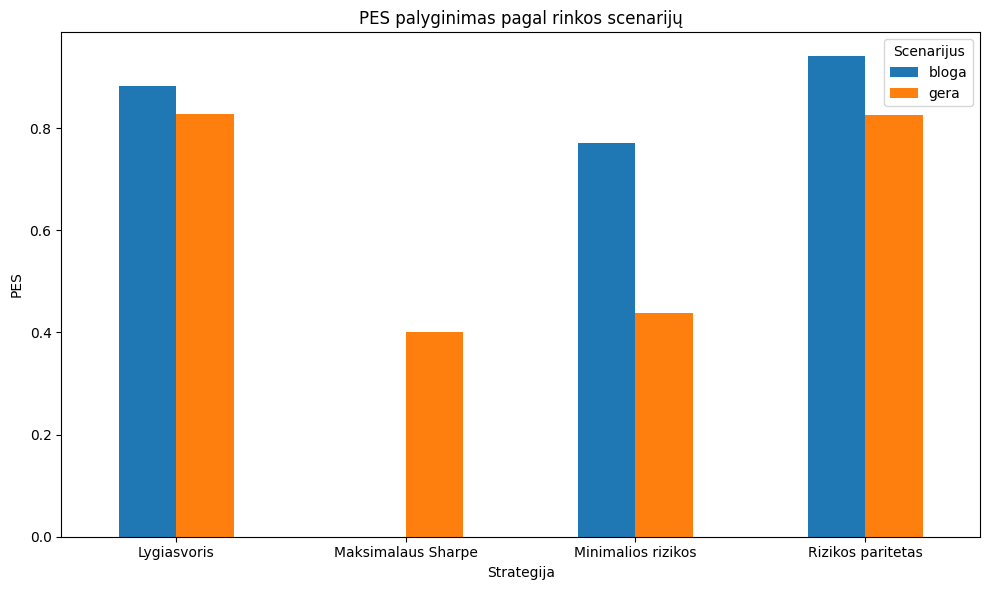

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. SUJUNGIAMI VISŲ STRATEGIJŲ REZULTATAI
# -------------------------------------------------

visi_rezultatai = pd.concat(
    [
        lygiasvorio_rezultatai_visi,
        minimalios_rizikos_rezultatai_visi,
        maks_sharpe_rezultatai_visi,
        rizikos_pariteto_rezultatai_visi
    ],
    ignore_index=True
)

visi_rezultatai.columns = visi_rezultatai.columns.astype(str).str.strip()

print("=== 1. VISI STRATEGIJŲ REZULTATAI ===")
print(visi_rezultatai.round(4))


# -------------------------------------------------
# 2. PES SKAIČIAVIMAS
# -------------------------------------------------

def min_max_normalizacija(serija, didesne_reiksme_geriau=True):
    min_reiksme = serija.min()
    max_reiksme = serija.max()

    if max_reiksme - min_reiksme == 0:
        return pd.Series(np.ones(len(serija)), index=serija.index)

    norm = (serija - min_reiksme) / (max_reiksme - min_reiksme)

    return norm if didesne_reiksme_geriau else 1 - norm


rezultatai_su_pes = visi_rezultatai.copy()
rezultatai_su_pes["Abs Max Drawdown"] = rezultatai_su_pes["Test maksimalus nuosmukis"].abs()

rezultatai_su_pes["Norm grąža"] = (
    rezultatai_su_pes.groupby("Scenarijus")["Test metinė grąža"]
    .transform(lambda x: min_max_normalizacija(x, True))
)

rezultatai_su_pes["Norm Sharpe"] = (
    rezultatai_su_pes.groupby("Scenarijus")["Test Sharpe"]
    .transform(lambda x: min_max_normalizacija(x, True))
)

rezultatai_su_pes["Norm rizika"] = (
    rezultatai_su_pes.groupby("Scenarijus")["Test metinė rizika"]
    .transform(lambda x: min_max_normalizacija(x, False))
)

rezultatai_su_pes["Norm nuosmukis"] = (
    rezultatai_su_pes.groupby("Scenarijus")["Abs Max Drawdown"]
    .transform(lambda x: min_max_normalizacija(x, False))
)

rezultatai_su_pes["Norm ENA"] = (
    rezultatai_su_pes.groupby("Scenarijus")["ENA"]
    .transform(lambda x: min_max_normalizacija(x, True))
)

rezultatai_su_pes["PES"] = (
    rezultatai_su_pes["Norm grąža"] +
    rezultatai_su_pes["Norm Sharpe"] +
    rezultatai_su_pes["Norm rizika"] +
    rezultatai_su_pes["Norm nuosmukis"] +
    rezultatai_su_pes["Norm ENA"]
) / 5

rezultatai_su_pes["PES reitingas"] = (
    rezultatai_su_pes.groupby("Scenarijus")["PES"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

print("\n=== 2. VISI REZULTATAI SU PES ===")
print(rezultatai_su_pes.round(4))


# -------------------------------------------------
# 3. PAGRINDINĖ LENTELĖ BLOGAI RINKAI
# -------------------------------------------------

rodyti_stulpelius = [
    "Scenarijus",
    "Strategija",
    "Test metinė grąža",
    "Test metinė rizika",
    "Test Sharpe",
    "Test maksimalus nuosmukis",
    "ENA",
    "PES",
    "PES reitingas"
]

bloga_lentele = (
    rezultatai_su_pes[rezultatai_su_pes["Scenarijus"] == "bloga"]
    .sort_values("PES", ascending=False)
    .reset_index(drop=True)
)

print("\n=== 3. BLOGOS RINKOS STRATEGIJŲ PALYGINIMAS ===")
print(bloga_lentele[rodyti_stulpelius].round(4))


# -------------------------------------------------
# 4. PAGRINDINĖ LENTELĖ GERAI RINKAI
# -------------------------------------------------

gera_lentele = (
    rezultatai_su_pes[rezultatai_su_pes["Scenarijus"] == "gera"]
    .sort_values("PES", ascending=False)
    .reset_index(drop=True)
)

print("\n=== 4. GEROS RINKOS STRATEGIJŲ PALYGINIMAS ===")
print(gera_lentele[rodyti_stulpelius].round(4))


# -------------------------------------------------
# 5. BENDRA SUVESTINĖ PER ABI RINKOS SĄLYGAS
# -------------------------------------------------

bendra_suvestine = (
    rezultatai_su_pes
    .groupby("Strategija", as_index=False)
    .agg({
        "Test metinė grąža": "mean",
        "Test metinė rizika": "mean",
        "Test Sharpe": "mean",
        "Test maksimalus nuosmukis": "mean",
        "ENA": "mean",
        "PES": "mean"
    })
    .sort_values("PES", ascending=False)
    .reset_index(drop=True)
)

bendra_suvestine["Bendras PES reitingas"] = (
    bendra_suvestine["PES"].rank(ascending=False, method="dense").astype(int)
)

print("\n=== 5. BENDRA STRATEGIJŲ SUVESTINĖ PER ABI RINKOS SĄLYGAS ===")
print(bendra_suvestine.round(4))


# -------------------------------------------------
# 6. GERIAUSIA STRATEGIJA PAGAL ATSKIRUS RODIKLIUS
# -------------------------------------------------

def geriausia_strategija(df, stulpelis, didesne_geriau=True):
    if didesne_geriau:
        eilute = df.loc[df[stulpelis].idxmax()]
    else:
        eilute = df.loc[df[stulpelis].idxmin()]

    return {
        "Rodiklis": stulpelis,
        "Geriausia strategija": eilute["Strategija"],
        "Reikšmė": eilute[stulpelis]
    }

rodikliu_santrauka = []

for scen in ["bloga", "gera"]:
    laikinas = rezultatai_su_pes[rezultatai_su_pes["Scenarijus"] == scen]

    rodikliu_santrauka.append({"Scenarijus": scen, **geriausia_strategija(laikinas, "Test metinė grąža", True)})
    rodikliu_santrauka.append({"Scenarijus": scen, **geriausia_strategija(laikinas, "Test Sharpe", True)})
    rodikliu_santrauka.append({"Scenarijus": scen, **geriausia_strategija(laikinas, "Test metinė rizika", False)})
    rodikliu_santrauka.append({"Scenarijus": scen, **geriausia_strategija(laikinas, "Test maksimalus nuosmukis", True)})
    rodikliu_santrauka.append({"Scenarijus": scen, **geriausia_strategija(laikinas, "ENA", True)})
    rodikliu_santrauka.append({"Scenarijus": scen, **geriausia_strategija(laikinas, "PES", True)})

rodikliu_santrauka_df = pd.DataFrame(rodikliu_santrauka)

print("\n=== 6. GERIAUSIOS STRATEGIJOS PAGAL ATSKIRUS RODIKLIUS ===")
print(rodikliu_santrauka_df.round(4))


# -------------------------------------------------
# 7. VIENAS GRAFIKAS: PES PALYGINIMAS
# -------------------------------------------------

pivot_pes = rezultatai_su_pes.pivot(index="Strategija", columns="Scenarijus", values="PES")
pivot_pes.plot(kind="bar", figsize=(10, 6))
plt.title("PES palyginimas pagal rinkos scenarijų")
plt.ylabel("PES")
plt.xticks(rotation=0)
plt.legend(title="Scenarijus")
plt.tight_layout()
plt.show()